In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import boxcox

from sklearn.preprocessing import StandardScaler,MinMaxScaler
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

from sklearn.preprocessing import PolynomialFeatures
from itertools import combinations

from sklearn.preprocessing import RobustScaler

import xgboost as xgb
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from itertools import product
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge, Lasso, BayesianRidge
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
import joblib

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from scipy.stats import loguniform, randint, uniform
from sklearn.feature_selection import f_regression

In [49]:
data=pd.read_excel("data - copie.xlsx")
data = data.replace({',': '.'}, regex=True)
data.columns=['p','v','h','t','Ra','Desnity','VED','LED','PED']
X_selected=['p','v','h','t']

data2=pd.read_excel('synthetic_data_gmm_1400.xlsx')
data2 = data2.replace({',': '.'}, regex=True)

data2.columns=['p','v','h','t','Ra']

data3 = pd.read_csv("synthetic_data_gans_filtre.csv", delimiter=',')
data3 = data3.replace({',': '.'}, regex=True)
data3.columns=['p','v','h','t','Ra']

df1 = data[['p', 'v', 'h', 't', 'Ra']]
df2 = data2[['p', 'v', 'h', 't', 'Ra']]
df3 = data3[['p', 'v', 'h', 't', 'Ra']]


merged_data = pd.concat([df1, df2, df3], ignore_index=True)
print(merged_data.shape)  

X_merged = merged_data[X_selected].values
y_merged = merged_data[['Ra']].values


(4291, 5)


In [50]:
def box_cox_fun(data, lambda_val=0.5):
    return ((data + 1e-5) ** lambda_val - 1) / lambda_val

def inverse_box_cox(data, lambda_val=0.5):
    if lambda_val == 0:
        return np.exp(data)
    else:
        return (data * lambda_val + 1) ** (1 / lambda_val) - 1e-5


In [51]:
data_extended =merged_data.copy()

data_extended['I(p^2)'] = data_extended['p']**2
data_extended['I(v^2)'] = data_extended['v']**2
data_extended['I(h^2)'] = data_extended['h']**2
data_extended['I(t^2)'] = data_extended['t']**2


data_extended['p:v'] = data_extended['p'] * data_extended['v']
data_extended['p:h'] = data_extended['p'] * data_extended['h']
data_extended['p:t'] = data_extended['p'] * data_extended['t']
data_extended['v:h'] = data_extended['v'] * data_extended['h']
data_extended['v:t'] = data_extended['v'] * data_extended['t']
data_extended['h:t'] = data_extended['h'] * data_extended['t']
data_extended['p:v:h'] = data_extended['p'] * data_extended['v'] * data_extended['h']
data_extended['p:v:t'] = data_extended['p'] * data_extended['v'] * data_extended['t']
data_extended['p:h:t'] = data_extended['p'] * data_extended['h'] * data_extended['t']
data_extended['v:h:t'] = data_extended['v'] * data_extended['h'] * data_extended['t']


variables = ['p', 'v', 'h', 't']

for var1, var2 in combinations(variables, 2):
    data_extended[f'I({var1}^2 * {var2})'] = (data_extended[var1]**2) * data_extended[var2]

for var1, var2, var3 in combinations(variables, 3):
    data_extended[f'I({var1}^2 * {var2} * {var3})'] = (data_extended[var1]**2) * (data_extended[var2]) * (data_extended[var3])






data_extended['I(sqrt(h)'] = np.sqrt(data_extended['h'])
data_extended['I(sqrt(v)'] = np.sqrt(data_extended['v'])
data_extended['I(sqrt(p)'] = np.sqrt(data_extended['p'])
data_extended['I(sqrt(t)'] = np.sqrt(data_extended['t'])

data_extended['I(sqrt(p) * v)'] = np.sqrt(data_extended['p']) * data_extended['v']
data_extended['I(sqrt(p) * h)'] = np.sqrt(data_extended['p']) * data_extended['h']
data_extended['I(sqrt(p) * t)'] = np.sqrt(data_extended['p']) * data_extended['t']

data_extended['I(sqrt(v) * p)'] = np.sqrt(data_extended['v']) * data_extended['p']
data_extended['I(sqrt(v) * h)'] = np.sqrt(data_extended['v']) * data_extended['h']
data_extended['I(sqrt(v) * t)'] = np.sqrt(data_extended['v']) * data_extended['t']

data_extended['I(sqrt(h) * p)'] = np.sqrt(data_extended['h']) * data_extended['p']
data_extended['I(sqrt(h) * v)'] = np.sqrt(data_extended['h']) * data_extended['v']
data_extended['I(sqrt(h) * t)'] = np.sqrt(data_extended['h']) * data_extended['t']

data_extended['I(sqrt(t) * p)'] = np.sqrt(data_extended['t']) * data_extended['p']
data_extended['I(sqrt(t) * v)'] = np.sqrt(data_extended['t']) * data_extended['v']
data_extended['I(sqrt(t) * h)'] = np.sqrt(data_extended['t']) * data_extended['h']

data_extended['I(p * sqrt(v))'] = data_extended['p'] * np.sqrt(data_extended['v'])
data_extended['I(sqrt(h) * t^2)'] = np.sqrt(data_extended['h']) * (data_extended['t']**2)
data_extended['I(p * h * sqrt(t))'] = data_extended['p'] * data_extended['h'] * np.sqrt(data_extended['t'])

data_extended['I(log(p) * v)'] = np.log(data_extended['p'] + 1e-6) * data_extended['v']
data_extended['I(log(p) * t)'] = np.log(data_extended['p'] + 1e-6) * data_extended['t']
data_extended['I(log(p) * h)'] = np.log(data_extended['p'] + 1e-6) * data_extended['h']
data_extended['I(log(v) * p)'] = np.log(data_extended['v'] + 1e-6) * data_extended['p']
data_extended['I(log(v) * h)'] = np.log(data_extended['v'] + 1e-6) * data_extended['h']
data_extended['I(log(v) * t)'] = np.log(data_extended['v'] + 1e-6) * data_extended['t']
data_extended['I(log(h) * p)'] = np.log(data_extended['h'] + 1e-6) * data_extended['p']
data_extended['I(log(h) * v)'] = np.log(data_extended['h'] + 1e-6) * data_extended['v']
data_extended['I(log(h) * t)'] = np.log(data_extended['h'] + 1e-6) * data_extended['t']
data_extended['I(log(t) * p)'] = np.log(data_extended['t'] + 1e-6) * data_extended['p']
data_extended['I(log(t) * h)'] = np.log(data_extended['t'] + 1e-6) * data_extended['h']
data_extended['I(log(t) * v)'] = np.log(data_extended['t'] + 1e-6) * data_extended['v']
data_extended["I(p * h^-1 * t^-1)"]=data_extended['p'] /( data_extended['v'] * data_extended['h'])
for var in variables:
    data_extended[f'I({var}^-1)'] = 1 / (data_extended[var] + 1e-6)


for var1 in variables:
    for var2 in variables:
        if var1 != var2:
            data_extended[f'I({var1} * {var2}^-1)'] = data_extended[var1] / (data_extended[var2] + 1e-6)


for r in range(2, len(variables) + 1):
    for combo in combinations(variables, r):
        
        col_name = 'I(' + ' * '.join([f'{v}^-1' for v in combo]) + ')'
        inv_product = np.ones(len(data_extended))
        for v in combo:
            inv_product *= 1 / (data_extended[v] + 1e-6)
        data_extended[col_name] = inv_product

In [52]:
from sklearn.feature_selection import f_regression, mutual_info_regression

X = data_extended.drop(columns=['Ra'], errors='ignore')

df_log = np.log(X)
scaler=RobustScaler()
X_standardized = scaler.fit_transform(df_log)


X_standardized = pd.DataFrame(X_standardized, columns=X.columns)
y = data_extended['Ra']

f_scores, p_values = f_regression(X_standardized, y)
anova_results = pd.DataFrame({
    'Variable': X_standardized.columns,
    'F-Score': f_scores,
    'p-value': p_values
})

anova_significant = anova_results[anova_results['p-value'] < 0.05]['Variable'].tolist()

mi_scores = mutual_info_regression(X_standardized, y)
mi_results = pd.DataFrame({
    'Variable': X_standardized.columns,
    'MI-Score': mi_scores
})

threshold = 0.1
mi_significant = mi_results[mi_results['MI-Score'] > threshold]['Variable'].tolist()

selected_vars = list(set(anova_significant) & set(mi_significant))

X_selected_vars = X[selected_vars]

print("Variables sélectionnées (communes entre ANOVA et Information Mutuelle) :")
print(selected_vars)


Variables sélectionnées (communes entre ANOVA et Information Mutuelle) :
['I(p * h^-1)', 'I(p^2 * t)', 'I(p^2 * v * t)', 'I(p^-1 * v^-1 * t^-1)', 't', 'I(p^-1 * h^-1)', 'I(sqrt(t) * h)', 'p:t', 'I(p * v^-1)', 'I(log(h) * t)', 'I(sqrt(p)', 'v', 'I(sqrt(p) * h)', 'p:v:t', 'I(h^-1)', 'I(sqrt(v) * h)', 'I(p^-1 * h^-1 * t^-1)', 'p:v:h', 'p', 'I(v^2)', 'I(v^-1 * h^-1 * t^-1)', 'I(p^-1 * v^-1 * h^-1)', 'p:h', 'v:h:t', 'I(sqrt(h) * t)', 'I(log(h) * v)', 'I(v^2 * h * t)', 'I(t * v^-1)', 'I(p^-1 * v^-1 * h^-1 * t^-1)', 'I(sqrt(v) * t)', 'I(sqrt(v) * p)', 'I(v^-1 * t^-1)', 'h', 'I(log(p) * h)', 'I(sqrt(h)', 'I(log(t) * h)', 'I(log(t) * v)', 'I(h * t^-1)', 'I(sqrt(t) * p)', 'I(h * v^-1)', 'I(p^2 * v)', 'I(sqrt(p) * t)', 'I(sqrt(h) * t^2)', 'I(log(v) * h)', 'I(v * p^-1)', 'I(p * sqrt(v))', 'I(p * h^-1 * t^-1)', 'I(v^2 * t)', 'I(t * h^-1)', 'I(p^-1 * t^-1)', 'I(log(t) * p)', 'I(p * t^-1)', 'p:v', 'I(sqrt(t)', 'I(h^2)', 'v:t', 'I(t^2)', 'I(h^-1 * t^-1)', 'I(log(p) * t)', 'I(p^-1 * v^-1)', 'I(sqrt(t) 

In [57]:
corr_matrix = X_selected_vars.corr().abs()

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.850)]

X_filtered = X_selected_vars.drop(columns=to_drop)

print(f"Variables supprimées car trop corrélées: {to_drop}")
print(f"Nombre de variables restantes: {X_filtered.shape[1]}")

Variables supprimées car trop corrélées: ['I(p^2 * v * t)', 'p:t', 'I(log(h) * t)', 'I(sqrt(p)', 'p:v:t', 'I(p^-1 * h^-1 * t^-1)', 'p', 'I(v^2)', 'I(v^-1 * h^-1 * t^-1)', 'I(p^-1 * v^-1 * h^-1)', 'p:h', 'I(sqrt(h) * t)', 'I(log(h) * v)', 'I(v^2 * h * t)', 'I(p^-1 * v^-1 * h^-1 * t^-1)', 'I(sqrt(v) * t)', 'I(sqrt(v) * p)', 'I(v^-1 * t^-1)', 'h', 'I(log(p) * h)', 'I(sqrt(h)', 'I(log(t) * h)', 'I(log(t) * v)', 'I(sqrt(t) * p)', 'I(p^2 * v)', 'I(sqrt(p) * t)', 'I(sqrt(h) * t^2)', 'I(log(v) * h)', 'I(p * sqrt(v))', 'I(p * h^-1 * t^-1)', 'I(v^2 * t)', 'I(t * h^-1)', 'I(p^-1 * t^-1)', 'I(log(t) * p)', 'p:v', 'I(sqrt(t)', 'I(h^2)', 'v:t', 'I(t^2)', 'I(log(p) * t)', 'I(p^-1 * v^-1)', 'I(sqrt(t) * v)', 'I(log(v) * p)', 'p:h:t', 'I(log(p) * v)', 'I(p * h * sqrt(t))', 'I(p^-1)', 'I(log(h) * p)', 'I(p^2 * h * t)', 'I(sqrt(v)', 'I(log(v) * t)', 'I(sqrt(h) * p)', 'I(h^2 * t)', 'v:h', 'I(p^2 * v * h)', 'I(v^-1)', 'I(v^-1 * h^-1)', 'I(t^-1)', 'I(p^2 * h)', 'I(p^2)', 'h:t']
Nombre de variables restantes

In [58]:
X_filtered

,I(p * h^-1),I(p^2 * t),I(p^-1 * v^-1 * t^-1),t,I(p^-1 * h^-1),I(sqrt(t) * h),I(p * v^-1),v,I(sqrt(p) * h),I(h^-1),...,I(t * v^-1),I(h * t^-1),I(h * v^-1),I(v * p^-1),I(p * t^-1),I(h^-1 * t^-1),I(v * t^-1),I(t * p^-1),I(h * p^-1),I(v * h^-1)
0,1.304348,5.625000e+05,6.666666e-07,25.000000,0.000058,575.000000,0.375000,400.000000,1408.456602,0.008696,...,0.062500,4.600000,0.287500,2.666667,6.000000,0.000348,15.999999,0.166667,0.766667,3.478261
1,1.304348,5.625000e+05,3.809524e-07,25.000000,0.000058,575.000000,0.214286,700.000000,1408.456602,0.008696,...,0.035714,4.600000,0.164286,4.666667,6.000000,0.000348,27.999999,0.166667,0.766667,6.086956
2,1.304348,5.625000e+05,2.666667e-07,25.000000,0.000058,575.000000,0.150000,1000.000000,1408.456602,0.008696,...,0.025000,4.600000,0.115000,6.666667,6.000000,0.000348,39.999998,0.166667,0.766667,8.695652
3,1.565217,8.100000e+05,5.555555e-07,25.000000,0.000048,575.000000,0.450000,400.000000,1542.886904,0.008696,...,0.062500,4.600000,0.287500,2.222222,7.200000,0.000348,15.999999,0.138889,0.638889,3.478261
4,1.565217,8.100000e+05,3.174603e-07,25.000000,0.000048,575.000000,0.257143,700.000000,1542.886904,0.008696,...,0.035714,4.600000,0.164286,3.888889,7.200000,0.000348,27.999999,0.138889,0.638889,6.086956
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4286,3.020502,7.705508e+06,6.456206e-08,55.739828,0.000022,919.012759,0.497483,747.376044,2373.545984,0.008124,...,0.074581,2.208376,0.164702,2.010117,6.670405,0.000146,13.408295,0.149916,0.331071,6.071562
4287,1.957905,1.445792e+06,2.297663e-07,25.688342,0.000035,614.131463,0.332194,714.155321,1866.318565,0.008253,...,0.035970,4.716906,0.169668,3.010286,9.235254,0.000321,27.800754,0.108281,0.510750,5.893854
4288,1.434281,9.234085e+05,2.207712e-07,28.640240,0.000044,669.981478,0.203862,880.789799,1677.562735,0.007988,...,0.032517,4.371171,0.142135,4.905279,6.269486,0.000279,30.753575,0.159503,0.697214,7.035546
4289,1.386738,7.504175e+05,6.281466e-07,24.898521,0.000046,624.679273,0.471372,368.299158,1649.501322,0.007988,...,0.067604,5.028017,0.339914,2.121466,6.972542,0.000321,14.792009,0.143420,0.721117,2.941917


In [ ]:
14	I(p * h^-1)	I(p^2 * t)	I(p^-1 * v^-1 * t^-1)	t	I(p^-1 * h^-1)	I(sqrt(t) * h)	I(p * v^-1)	v	I(sqrt(v) * h)	I(t * v^-1)	I(h * t^-1)	I(h * v^-1)	I(p * t^-1)	I(v * t^-1)

In [48]:
X_selected=["I(log(v) * t)"	,"h:t",	"I(v^-1)",	"I(v * p^-1)"	,"I(t * p^-1)",	"I(log(p) * h)"	,"I(p * v^-1)"	,"I(v * t^-1)"]

In [ ]:
X_selected_20=["I(log(t) * p)",	"I(sqrt(v) * h)",	"I(log(p) * t)"	,"I(h^-1 * t^-1)",	"I(v * p^-1)"	,"I(v^2 * h * t)"	,"I(p * h^-1 * t^-1)"	,"I(sqrt(p) * h)"	,"I(p^-1 * v^-1 * t^-1)",	"I(h * t^-1)"	,"I(p^-1 * t^-1)"	,"I(v^2)"	,"I(v^-1 * t^-1)"	,"I(h * p^-1)"	,"I(v * t^-1)",	"I(h * v^-1)",	"I(t * v^-1)",	"I(t * p^-1)"	,"I(v^-1 * h^-1)"	,"I(v * h^-1)"]

In [45]:
X_selected=["p","v","h","t","I(p^2)",	"I(v * h^-1)",	"I(log(p) * h)",	"I(p * v^-1)",	"I(t^2)",	"I(v^-1)",	"I(p^-1 * h^-1)",	"I(log(h) * v)",	"I(t * h^-1)",	"I(h * p^-1)",	"I(t * p^-1)",	"I(v * t^-1)"]

In [55]:
X_selected=["p","v","h","t","I(p * v^-1)","I(p * h^-1 * t^-1)"]

In [59]:

X=X_filtered.values
epsilon = 1e-6
df_log = np.log(X)



scaler=RobustScaler()
X_scaled =scaler.fit_transform(df_log)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_merged, 
    test_size=0.30, 
    random_state=42,shuffle=True)
y_train_bc=box_cox_fun(y_train)
y_test_bc=box_cox_fun(y_test)

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, PReLU, Dropout
from tensorflow.keras.optimizers import Adam, AdamW, RMSprop, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau



# ---------- Choix de l'optimizer ----------
def get_optimizer(name, lr):
    return {
        'adam': Adam(learning_rate=lr),
        'adamw': AdamW(learning_rate=lr, weight_decay=1e-4),
        'rmsprop': RMSprop(learning_rate=lr),
        
    }[name.lower()]

# ---------- Construction du modèle ----------
def build_model(input_dim, optimizer_name, learning_rate, variant="deep"):
    opt = get_optimizer(optimizer_name, learning_rate)

    layers = []
    
    if variant == "deep":
        layers = [
            Dense(512, input_dim=input_dim), BatchNormalization(), PReLU(),
            Dense(256), BatchNormalization(), PReLU(), Dropout(0.3),
            Dense(128), BatchNormalization(), PReLU(), Dropout(0.3),
            Dense(64), BatchNormalization(), PReLU(), Dropout(0.3),
            Dense(32), BatchNormalization(), PReLU(), Dropout(0.3),
            Dense(16), BatchNormalization(), PReLU(), Dropout(0.2)
        ]
        

    layers.append(Dense(1, activation='linear'))

    model = Sequential(layers)
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    return model

# ---------- Callbacks ----------
early_stopping = EarlyStopping(monitor='val_loss', patience=70, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, verbose=0)

# ---------- Grilles d’hyperparamètres ----------
optimizers = ['adam', 'adamw', 'rmsprop']
learning_rates = [0.001, 0.005,0.01]
batch_sizes = [ 64,128,256]
architectures = ['deep']

# ---------- Recherche ----------
best_score = -np.inf  
best_params = {}
best_model = None
results = []

for arch in architectures:
    for opt_name in optimizers:
        for lr in learning_rates:
            for bs in batch_sizes:
                print(f"\n🔵 Test: arch={arch}, optimizer={opt_name}, lr={lr}, batch={bs}")

                model = build_model(X_train.shape[1], opt_name, lr, arch)
                
                history = model.fit(
                    X_train, y_train_bc,
                    epochs=5000,
                    batch_size=bs,
                    validation_data=(X_test, y_test_bc),
                    verbose=0,
                    callbacks=[early_stopping, reduce_lr]
                )
                
                preds = model.predict(X_test).squeeze()
                preds = inverse_box_cox(preds)
                
                rmse = np.sqrt(mean_squared_error(y_test, preds))
                mae = mean_absolute_error(y_test, preds)
                r2 = r2_score(y_test, preds)
                
                results.append({
                    'arch': arch,
                    'optimizer': opt_name,
                    'learning_rate': lr,
                    'batch_size': bs,
                    'RMSE': rmse,
                    'MAE': mae,
                    'R2': r2
                })
                
                if r2 > best_score:
                    best_score = r2
                    best_params = {'arch': arch, 'optimizer': opt_name, 'learning_rate': lr, 'batch_size': bs}
                    best_model = model

# ---------- Résultats ----------
results_df = pd.DataFrame(results)
print("\n📊 Résumé des tests (classé par R² décroissant) :")
print(results_df.sort_values('R2', ascending=False))

print("\n✅ Meilleurs hyperparamètres trouvés :")
print(best_params)
print(f"🎯 Meilleur R² : {best_score:.4f}")

# ---------- Prédictions finales ----------
y_pred_final = best_model.predict(X_test)
y_pred_final = inverse_box_cox(y_pred_final)
print("\n📈 Résultats finaux sur le test set :")
print(f"R2 : {r2_score(y_test, y_pred_final):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred_final):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_final)):.4f}")





🔵 Test: arch=deep, optimizer=adam, lr=0.001, batch=64
41/41 [==============================] - 0s 2ms/step

🔵 Test: arch=deep, optimizer=adam, lr=0.001, batch=128
41/41 [==============================] - 0s 2ms/step

🔵 Test: arch=deep, optimizer=adam, lr=0.001, batch=256
41/41 [==============================] - 0s 3ms/step

🔵 Test: arch=deep, optimizer=adam, lr=0.005, batch=64
41/41 [==============================] - 0s 3ms/step

🔵 Test: arch=deep, optimizer=adam, lr=0.005, batch=128
41/41 [==============================] - 0s 2ms/step

🔵 Test: arch=deep, optimizer=adam, lr=0.005, batch=256
41/41 [==============================] - 0s 3ms/step

🔵 Test: arch=deep, optimizer=adam, lr=0.01, batch=64
41/41 [==============================] - 0s 2ms/step

🔵 Test: arch=deep, optimizer=adam, lr=0.01, batch=128
41/41 [==============================] - 0s 3ms/step

🔵 Test: arch=deep, optimizer=adam, lr=0.01, batch=256
41/41 [==============================] - 0s 4ms/step

🔵 Test: arch=deep, optim

In [68]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, PReLU
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.optimizers import Adam, SGD, RMSprop, AdamW


def build_best_model(input_dim):
    model = Sequential([
        Dense(512, input_dim=input_dim),
        BatchNormalization(),
        PReLU(),

       
        Dense(256),
        BatchNormalization(),
        PReLU(),
        Dropout(0.3),

        Dense(128),
        BatchNormalization(),
        PReLU(),
        Dropout(0.3),

        Dense(64),
        BatchNormalization(),
        PReLU(),
        Dropout(0.3),

        Dense(32),
        BatchNormalization(),
        PReLU(),
        Dropout(0.3),

        Dense(16),
        BatchNormalization(),
        PReLU(),
        Dropout(0.2),

        Dense(1, activation='relu')
    ])

    optimizer = AdamW(learning_rate=0.005)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=70,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, verbose=0)

model = build_best_model(X_train.shape[1])

history = model.fit(
    X_train, y_train_bc,
    epochs=5000,
    batch_size=128,
    validation_data=(X_test, y_test_bc),
    verbose=1,
    callbacks=[reduce_lr,early_stopping]
)


y_pred_final = model.predict(X_test)
y_pred_final = inverse_box_cox(y_pred_final)


print("\n📈 Résultats finaux sur le test set :")
print(f"R2 : {r2_score(y_test, y_pred_final):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred_final):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_final)):.4f}")


Epoch 1/5000
24/24 [==============================] - 6s 117ms/step - loss: 12.8183 - mae: 3.3031 - val_loss: 8.0470 - val_mae: 2.4349 - lr: 0.0050
Epoch 2/5000
24/24 [==============================] - 1s 36ms/step - loss: 6.7311 - mae: 2.1664 - val_loss: 6.1568 - val_mae: 2.1637 - lr: 0.0050
Epoch 3/5000
24/24 [==============================] - 1s 37ms/step - loss: 2.1852 - mae: 1.1456 - val_loss: 5.1395 - val_mae: 1.8170 - lr: 0.0050
Epoch 4/5000
24/24 [==============================] - 2s 82ms/step - loss: 1.5404 - mae: 0.9558 - val_loss: 2.9723 - val_mae: 1.4297 - lr: 0.0050
Epoch 5/5000
24/24 [==============================] - 2s 94ms/step - loss: 1.4438 - mae: 0.9000 - val_loss: 2.1052 - val_mae: 1.2254 - lr: 0.0050
Epoch 6/5000
24/24 [==============================] - 2s 99ms/step - loss: 1.2364 - mae: 0.8464 - val_loss: 1.1537 - val_mae: 0.9091 - lr: 0.0050
Epoch 7/5000
24/24 [==============================] - 2s 84ms/step - loss: 1.1916 - mae: 0.8339 - val_loss: 0.9935 - val_m

In [12]:
import optuna
from pytorch_tabnet.tab_model import TabNetRegressor
import torch
from sklearn.metrics import mean_squared_error

import warnings


warnings.filterwarnings("ignore", message="Best weights from best epoch are automatically used!")

def objective(trial):
    params = {
        'n_d': trial.suggest_categorical('n_d', [ 64, 128, 256]),
        'n_a': trial.suggest_categorical('n_a', [ 64, 128, 256]),
        'n_steps': trial.suggest_int('n_steps', 3, 8),
        'gamma': trial.suggest_float('gamma', 1.0, 2.0),
        'lambda_sparse': trial.suggest_float('lambda_sparse', 1e-7, 1e-3, log=True),
        'optimizer_fn': torch.optim.Adam,
        'optimizer_params': dict(lr=trial.suggest_float('lr', 1e-4, 1e-2, log=True)),
        'mask_type': trial.suggest_categorical('mask_type', ['sparsemax', 'entmax']),
        'scheduler_params': {"step_size": 50, "gamma": 0.9},
        'scheduler_fn': torch.optim.lr_scheduler.StepLR,
        'verbose': 0,
    }

    # Optimisation de batch_size
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])
    virtual_batch_size = batch_size // 2 

    model = TabNetRegressor(**params)

    model.fit(
        X_train=X_train,
        y_train=y_train_bc,
        eval_set=[(X_test, y_test_bc)],
        eval_metric=['rmse'],
        patience=40,
        max_epochs=300,
        batch_size=batch_size,
        virtual_batch_size=virtual_batch_size,
        num_workers=0
    )

    preds = model.predict(X_test)
    score = np.sqrt(mean_squared_error(y_test_bc, preds))  # RMSE

    return score


# Lancement de l'optimisation
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

# Affichage des meilleurs résultats
print("Best trial:")
print(study.best_trial)
print("Best params:")
print(study.best_params)


c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-05-14 19:34:40,092] A new study created in memory with name: no-name-e6ce99d5-db3e-4cb7-a3b1-f42fe79a9943



Early stopping occurred at epoch 171 with best_epoch = 131 and best_val_0_rmse = 0.34355


[I 2025-05-14 19:43:24,451] Trial 0 finished with value: 0.34354924321864466 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.3698593889766761, 'lambda_sparse': 2.0741506866555107e-07, 'lr': 0.004685570033458107, 'mask_type': 'entmax', 'batch_size': 64}. Best is trial 0 with value: 0.34354924321864466.


Stop training because you reached max_epochs = 300 with best_epoch = 299 and best_val_0_rmse = 0.38482


[I 2025-05-14 20:10:20,141] Trial 1 finished with value: 0.38481951195607744 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 6, 'gamma': 1.1175795337804582, 'lambda_sparse': 5.4221437486440136e-05, 'lr': 0.0009414154938852186, 'mask_type': 'sparsemax', 'batch_size': 64}. Best is trial 0 with value: 0.34354924321864466.


...


Early stopping occurred at epoch 233 with best_epoch = 193 and best_val_0_rmse = 0.36609


[I 2025-05-15 02:44:16,173] Trial 48 finished with value: 0.366089905860329 and parameters: {'n_d': 128, 'n_a': 64, 'n_steps': 4, 'gamma': 1.8692814015766486, 'lambda_sparse': 1.5140404602536352e-06, 'lr': 0.0009834581730958653, 'mask_type': 'entmax', 'batch_size': 64}. Best is trial 28 with value: 0.31787220256084775.



Early stopping occurred at epoch 230 with best_epoch = 190 and best_val_0_rmse = 0.3333


[I 2025-05-15 02:51:19,227] Trial 49 finished with value: 0.33330172727740465 and parameters: {'n_d': 256, 'n_a': 128, 'n_steps': 3, 'gamma': 1.6692120750459611, 'lambda_sparse': 6.551420652833047e-05, 'lr': 0.004232631058082603, 'mask_type': 'entmax', 'batch_size': 128}. Best is trial 28 with value: 0.31787220256084775.


Best trial:
FrozenTrial(number=28, state=TrialState.COMPLETE, values=[0.31787220256084775], datetime_start=datetime.datetime(2025, 5, 14, 23, 57, 20, 659528), datetime_complete=datetime.datetime(2025, 5, 15, 0, 8, 16, 33492), params={'n_d': 256, 'n_a': 64, 'n_steps': 5, 'gamma': 1.903700388490685, 'lambda_sparse': 8.982770379077133e-05, 'lr': 0.009495452313595672, 'mask_type': 'entmax', 'batch_size': 128}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_d': CategoricalDistribution(choices=(64, 128, 256)), 'n_a': CategoricalDistribution(choices=(64, 128, 256)), 'n_steps': IntDistribution(high=8, log=False, low=3, step=1), 'gamma': FloatDistribution(high=2.0, log=False, low=1.0, step=None), 'lambda_sparse': FloatDistribution(high=0.001, log=True, low=1e-07, step=None), 'lr': FloatDistribution(high=0.01, log=True, low=0.0001, step=None), 'mask_type': CategoricalDistribution(choices=('sparsemax', 'entmax')), 'batch_size': CategoricalDistribution(choices=(64, 128, 

In [35]:
from pytorch_tabnet.tab_model import TabNetRegressor
import torch
tabnet_model = TabNetRegressor(
    n_d=128,
    n_a=128,
    n_steps=5,
    gamma=1.903700388490685,
    lambda_sparse=8.982770379077133e-05,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.009495452313595672),
    mask_type='entmax'
)


tabnet_model.fit(
    X_train,
    y_train_bc,
    eval_set=[(X_test, y_test_bc)],
    eval_metric=['rmse'],
    patience=40,
    max_epochs=300,
    batch_size=128,
    virtual_batch_size=64,
    num_workers=0
)

y_pred_tabnet_bc = tabnet_model.predict(X_test)
y_pred_tabnet = inverse_box_cox(y_pred_tabnet_bc)


r2_tabnet = r2_score(y_test, y_pred_tabnet)
rmse_tabnet = np.sqrt(mean_squared_error(y_test, y_pred_tabnet))
mae_tabnet = mean_absolute_error(y_test, y_pred_tabnet)
mape_tabnet = np.mean(np.abs((y_test - y_pred_tabnet) / y_test)) * 100

print(f"R2: {r2_tabnet:.4f}")
print(f"RMSE: {rmse_tabnet:.4f}")
print(f"MAE: {mae_tabnet:.4f}")
print(f"MAPE: {mape_tabnet:.4f}")


c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 7.35119 | val_0_rmse: 2.08434 |  0:00:01s
epoch 1  | loss: 3.2534  | val_0_rmse: 1.37588 |  0:00:03s
epoch 2  | loss: 1.52521 | val_0_rmse: 1.33645 |  0:00:04s
epoch 3  | loss: 1.17214 | val_0_rmse: 1.06027 |  0:00:06s
epoch 4  | loss: 1.0523  | val_0_rmse: 0.91618 |  0:00:08s
epoch 5  | loss: 0.70355 | val_0_rmse: 0.76498 |  0:00:09s
epoch 6  | loss: 0.76006 | val_0_rmse: 0.91771 |  0:00:11s
epoch 7  | loss: 0.69825 | val_0_rmse: 0.76126 |  0:00:12s
epoch 8  | loss: 0.59844 | val_0_rmse: 0.67855 |  0:00:14s
epoch 9  | loss: 0.55419 | val_0_rmse: 0.71442 |  0:00:15s
epoch 10 | loss: 0.54543 | val_0_rmse: 0.83779 |  0:00:17s
epoch 11 | loss: 0.56812 | val_0_rmse: 0.76986 |  0:00:19s
epoch 12 | loss: 0.54953 | val_0_rmse: 0.52777 |  0:00:20s
epoch 13 | loss: 0.45391 | val_0_rmse: 0.70892 |  0:00:22s
epoch 14 | loss: 0.49465 | val_0_rmse: 0.72414 |  0:00:23s
epoch 15 | loss: 0.68329 | val_0_rmse: 0.75744 |  0:00:25s
epoch 16 | loss: 0.43959 | val_0_rmse: 0.61849 |  0:00:2

c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


R2: 0.9370
RMSE: 1.1138
MAE: 0.7311
MAPE: 8.6231


In [ ]:

from sklearn.ensemble import RandomForestRegressor
import optuna


def objective(trial):
   
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
        'max_depth': trial.suggest_int('max_depth', 5, 30, step=1),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20, step=1),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10, step=1),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False])
    }
    
    
    rf = RandomForestRegressor(**params)
    rf.fit(X_train, y_train_bc.ravel())
    
    y_pred_bc_rf = rf.predict(X_test)
    y_pred_rf = inverse_box_cox(y_pred_bc_rf)
    
    rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
    
    
    return rmse_rf


study = optuna.create_study(direction="minimize")  
study.optimize(objective, n_trials=100)  


print("Best trial:")
print(study.best_trial)
print("Best params:")
print(study.best_params)


c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-05-15 10:23:51,458] A new study created in memory with name: no-name-3a915d55-a7e0-4f8f-8c95-1a6c74193d8c
[I 2025-05-15 10:23:54,835] Trial 0 finished with value: 1.7374634971456948 and parameters: {'n_estimators': 600, 'max_depth': 10, 'min_samples_split': 3, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 1.7374634971456948.
[I 2025-05-15 10:24:14,939] Trial 1 finished with value: 1.613359196277 and parameters: {'n_estimators': 800, 'max_depth': 26, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': None, 'bootstrap': True}. Best is trial 1 with value: 1.613359196277.
[I 2025-05-15 10:24:16,942] Trial 2 finished with value: 2.3422048192718523

Best trial:
FrozenTrial(number=61, state=TrialState.COMPLETE, values=[1.2908968723223675], datetime_start=datetime.datetime(2025, 5, 15, 10, 30, 16, 503364), datetime_complete=datetime.datetime(2025, 5, 15, 10, 30, 20, 316042), params={'n_estimators': 300, 'max_depth': 22, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': False}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=1000, log=False, low=100, step=100), 'max_depth': IntDistribution(high=30, log=False, low=5, step=1), 'min_samples_split': IntDistribution(high=20, log=False, low=2, step=1), 'min_samples_leaf': IntDistribution(high=10, log=False, low=1, step=1), 'max_features': CategoricalDistribution(choices=('sqrt', 'log2', None)), 'bootstrap': CategoricalDistribution(choices=(True, False))}, trial_id=61, value=None)
Best params:
{'n_estimators': 300, 'max_depth': 22, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log

In [37]:

rf = RandomForestRegressor(bootstrap= False, max_depth=22, max_features='log2', min_samples_leaf= 1, min_samples_split= 4, n_estimators= 300)


rf.fit(X_train, y_train_bc.ravel())
y_pred_bc_rf = rf.predict(X_test)
y_pred_rf = inverse_box_cox(y_pred_bc_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100
print(f"R2: {r2_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")
print(f"mape: {mape_rf:.4f}")

R2: 0.9122
RMSE: 1.3145
MAE: 0.7132
mape: 47.9187


Fitting 5 folds for each of 150 candidates, totalling 750 fits

--- Meilleur SVR trouvé ---
Best params: {'C': 5, 'epsilon': 0.1, 'gamma': 1, 'kernel': 'rbf'}
R2: 0.9232
RMSE: 1.2294
MAE: 0.6936
MAPE: 48.53%


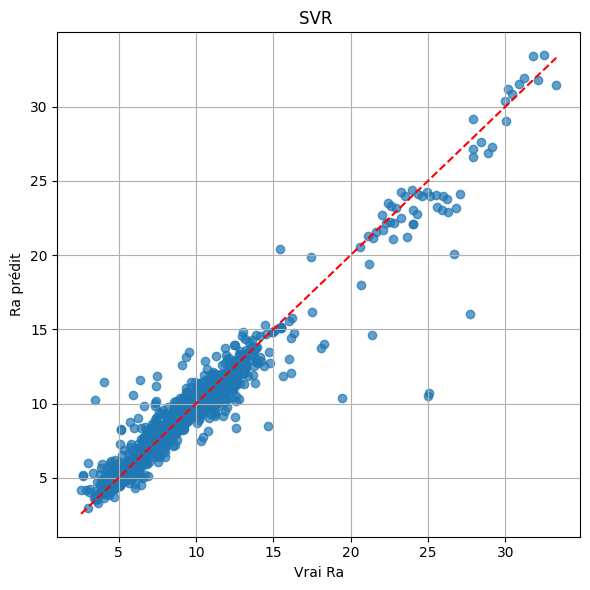

In [38]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

param_grid_svr = {
    'C': [0.1,0.5, 1,5,10],
    'epsilon': [0.01, 0.05, 0.1, 0.2, 0.5],
    'kernel': ['rbf'],
     
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
}

svr = SVR()
grid_svr = GridSearchCV(
    svr,
    param_grid=param_grid_svr,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=2,
    n_jobs=-1
)

grid_svr.fit(X_train, y_train_bc.ravel())
best_svr = grid_svr.best_estimator_


y_pred_bc_svr = best_svr.predict(X_test)
y_pred_svr = inverse_box_cox(y_pred_bc_svr)


rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)
mape_svr = np.mean(np.abs((y_test - y_pred_svr) / y_test)) * 100

print("\n--- Meilleur SVR trouvé ---")
print(f"Best params: {grid_svr.best_params_}")
print(f"R2: {r2_svr:.4f}")
print(f"RMSE: {rmse_svr:.4f}")
print(f"MAE: {mae_svr:.4f}")
print(f"MAPE: {mape_svr:.2f}%")

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_svr, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel("Vrai Ra")
plt.ylabel("Ra prédit")
plt.title("SVR ")
plt.grid(True)
plt.tight_layout()
plt.show()


In [39]:
from sklearn.tree import DecisionTreeRegressor

param_grid = {
    'max_depth': [4, 6, 8, 10, 12, None],
    'min_samples_split': [2, 4, 6, 8],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': [None, 'sqrt', 'log2']
}


grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)


grid_search.fit(X_train, y_train_bc.ravel())


best_tree = grid_search.best_estimator_
print("Best hyperparameters:", grid_search.best_params_)


y_pred_bc_tree = best_tree.predict(X_test)
y_pred_tree = inverse_box_cox(y_pred_bc_tree)




rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
mae_tree = mean_absolute_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)
mape_tree = np.mean(np.abs((y_test - y_pred_tree) / y_test)) * 100

print("\n--- Decision Tree ---")
print(f"R2: {r2_tree:.4f}")
print(f"RMSE: {rmse_tree:.4f}")
print(f"MAE: {mae_tree:.4f}")
print(f"MAPE: {mape_tree:.2f}%")




Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 8}

--- Decision Tree ---
R2: 0.8148
RMSE: 1.9093
MAE: 1.0705
MAPE: 49.87%


In [ ]:

from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint, uniform


param_dist = {
    'max_depth': randint(3, 12),
    'learning_rate': loguniform(1e-4, 0.1),
    'n_estimators': randint(200, 1000),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'gamma': uniform(0, 0.3),
    'min_child_weight': randint(1, 10),
    'reg_alpha': uniform(0, 0.5),
    'reg_lambda': uniform(0, 0.5),
    'scale_pos_weight': uniform(1, 2),
    'max_delta_step': randint(1, 10),
    'min_split_loss': uniform(0, 0.3)
}

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_jobs=-1,
    early_stopping_rounds=50, 
    eval_metric='rmse'
)

random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist,
    n_iter=3000,               
    cv=5,                     
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_train, y_train_bc,
    test_size=0.15,
    random_state=42
)

random_search.fit(
    X_train_part, y_train_part,
    eval_set=[(X_val, y_val)],
    verbose=False
)

best_model_xgb = random_search.best_estimator_
print(best_model_xgb)
y_pred = best_model_xgb.predict(X_test)
y_pred_original = inverse_box_cox(y_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_original))
mae_xgb = mean_absolute_error(y_test, y_pred_original)
r2_xgb = r2_score(y_test, y_pred_original)

print(f"R2: {r2_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"MAE: {mae_xgb:.4f}")


Fitting 5 folds for each of 3000 candidates, totalling 15000 fits


NameError: name 'best_model' is not defined

In [41]:
best_model_xgb = random_search.best_estimator_
print(best_model_xgb)
y_pred = best_model_xgb.predict(X_test)
y_pred_original = inverse_box_cox(y_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_original))
mae_xgb = mean_absolute_error(y_test, y_pred_original)
r2_xgb = r2_score(y_test, y_pred_original)

print(f"R2: {r2_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"MAE: {mae_xgb:.4f}")

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7270416955367828, device=None,
             early_stopping_rounds=50, enable_categorical=False,
             eval_metric='rmse', feature_types=None, feature_weights=None,
             gamma=0.06193166534314432, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.020566941497490963,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=2, max_depth=8, max_leaves=None, min_child_weight=5,
             min_split_loss=0.05729460916206087, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=860,
             n_jobs=-1, ...)
R2: 0.9247
RMSE: 1.2178
MAE: 0.7216


In [42]:
from catboost import CatBoostRegressor
cat_model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.01,
    depth=10,
    loss_function='RMSE',
    verbose=0,
   
)

cat_model.fit(X_train, y_train_bc)

y_pred_cat_bc = cat_model.predict(X_test)
y_pred_cat=inverse_box_cox(y_pred_cat_bc)

r2_cat = r2_score(y_test, y_pred_cat)
rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
mae_cat = mean_absolute_error(y_test, y_pred_cat)
mape_cat = np.mean(np.abs((y_test - y_pred_cat) / y_test)) * 100
print(f"R2: {r2_cat:.4f}")
print(f"RMSE: {rmse_cat:.4f}")
print(f"MAE: {mae_cat:.4f}")
print(f"MAPE: {mape_cat:.4f}")

R2: 0.9335
RMSE: 1.1439
MAE: 0.6754
MAPE: 48.4774
